In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
path = '../datasets/bitly_usagov/example.txt'

In [3]:
with open(path) as f:
    print(f.readline())

{ "a": "Mozilla\/5.0 (Windows NT 6.1; WOW64) AppleWebKit\/535.11 (KHTML, like Gecko) Chrome\/17.0.963.78 Safari\/535.11", "c": "US", "nk": 1, "tz": "America\/New_York", "gr": "MA", "g": "A6qOVH", "h": "wfLQtf", "l": "orofrog", "al": "en-US,en;q=0.8", "hh": "1.usa.gov", "r": "http:\/\/www.facebook.com\/l\/7AQEFzjSi\/1.usa.gov\/wfLQtf", "u": "http:\/\/www.ncbi.nlm.nih.gov\/pubmed\/22415991", "t": 1331923247, "hc": 1331822918, "cy": "Danvers", "ll": [ 42.576698, -70.954903 ] }



In [4]:
import json
with open(path) as f:
    records = [json.loads(line) for line in f]

In [5]:
records[0]

{'a': 'Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebKit/535.11 (KHTML, like Gecko) Chrome/17.0.963.78 Safari/535.11',
 'c': 'US',
 'nk': 1,
 'tz': 'America/New_York',
 'gr': 'MA',
 'g': 'A6qOVH',
 'h': 'wfLQtf',
 'l': 'orofrog',
 'al': 'en-US,en;q=0.8',
 'hh': '1.usa.gov',
 'r': 'http://www.facebook.com/l/7AQEFzjSi/1.usa.gov/wfLQtf',
 'u': 'http://www.ncbi.nlm.nih.gov/pubmed/22415991',
 't': 1331923247,
 'hc': 1331822918,
 'cy': 'Danvers',
 'll': [42.576698, -70.954903]}

In [7]:
time_zones = [rec['tz'] for rec in records if 'tz' in rec]

In [8]:
time_zones[:10]

['America/New_York',
 'America/Denver',
 'America/New_York',
 'America/Sao_Paulo',
 'America/New_York',
 'America/New_York',
 'Europe/Warsaw',
 '',
 '',
 '']

In [9]:
def get_counts(sequence):
    counts = {}
    for x in sequence:
        if x in counts:
            counts[x] +=1
        else:
            counts[x] = 1
    return counts

In [11]:
from collections import defaultdict
def get_counts2(sequence):
    counts = defaultdict(int)
    for x in sequence:
        counts[x] += 1
    return counts

In [12]:
counts = get_counts(time_zones)

In [13]:
counts['America/New_York']

1251

In [14]:
len(time_zones)

3440

In [16]:
def top_counts(counts_dict, n=10):
    value_key_pairs = [(counts, tz) for tz, count in counts_dict.items()]
    value_key_pairs.sort()
    return value_key_pairs[-n:]

In [17]:
top_counts(counts)

[({'America/New_York': 1251,
   'America/Denver': 191,
   'America/Sao_Paulo': 33,
   'Europe/Warsaw': 16,
   '': 521,
   'America/Los_Angeles': 382,
   'Asia/Hong_Kong': 10,
   'Europe/Rome': 27,
   'Africa/Ceuta': 2,
   'Europe/Madrid': 35,
   'Asia/Kuala_Lumpur': 3,
   'Asia/Nicosia': 1,
   'Europe/London': 74,
   'Pacific/Honolulu': 36,
   'America/Chicago': 400,
   'Europe/Malta': 2,
   'Europe/Lisbon': 8,
   'Europe/Paris': 14,
   'Europe/Copenhagen': 5,
   'America/Mazatlan': 1,
   'Europe/Dublin': 3,
   'Europe/Brussels': 4,
   'America/Vancouver': 12,
   'Europe/Amsterdam': 22,
   'Europe/Prague': 10,
   'Europe/Stockholm': 14,
   'America/Anchorage': 5,
   'Asia/Bangkok': 6,
   'Europe/Berlin': 28,
   'America/Rainy_River': 25,
   'Europe/Budapest': 5,
   'Asia/Tokyo': 37,
   'Europe/Vienna': 6,
   'America/Phoenix': 20,
   'Asia/Jerusalem': 3,
   'Asia/Karachi': 3,
   'America/Bogota': 3,
   'America/Indianapolis': 20,
   'America/Montreal': 9,
   'Asia/Calcutta': 9,
   'Eur

In [18]:
from collections import Counter

In [20]:
counts = Counter(time_zones)

In [21]:
counts.most_common(10)

[('America/New_York', 1251),
 ('', 521),
 ('America/Chicago', 400),
 ('America/Los_Angeles', 382),
 ('America/Denver', 191),
 ('Europe/London', 74),
 ('Asia/Tokyo', 37),
 ('Pacific/Honolulu', 36),
 ('Europe/Madrid', 35),
 ('America/Sao_Paulo', 33)]

In [22]:
frame = pd.DataFrame(records)

In [23]:
frame.info()

<class 'pandas.DataFrame'>
RangeIndex: 3560 entries, 0 to 3559
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   a            3440 non-null   str    
 1   c            2919 non-null   str    
 2   nk           3440 non-null   float64
 3   tz           3440 non-null   str    
 4   gr           2919 non-null   str    
 5   g            3440 non-null   str    
 6   h            3440 non-null   str    
 7   l            3440 non-null   str    
 8   al           3094 non-null   str    
 9   hh           3440 non-null   str    
 10  r            3440 non-null   str    
 11  u            3440 non-null   str    
 12  t            3440 non-null   float64
 13  hc           3440 non-null   float64
 14  cy           2919 non-null   str    
 15  ll           2919 non-null   object 
 16  _heartbeat_  120 non-null    float64
 17  kw           93 non-null     str    
dtypes: float64(4), object(1), str(13)
memory usage: 1.4+ MB


In [24]:
frame['tz'].head()

0     America/New_York
1       America/Denver
2     America/New_York
3    America/Sao_Paulo
4     America/New_York
Name: tz, dtype: str

In [25]:
tz_counts = frame['tz'].value_counts()

In [26]:
tz_counts.head()

tz
America/New_York       1251
                        521
America/Chicago         400
America/Los_Angeles     382
America/Denver          191
Name: count, dtype: int64

In [27]:
clean_tz = frame['tz'].fillna('Missing')

In [28]:
clean_tz[clean_tz == ''] = 'Unknown'

In [29]:
tz_counts = clean_tz.value_counts()

In [30]:
tz_counts.head()

tz
America/New_York       1251
Unknown                 521
America/Chicago         400
America/Los_Angeles     382
America/Denver          191
Name: count, dtype: int64

<Axes: ylabel='tz'>

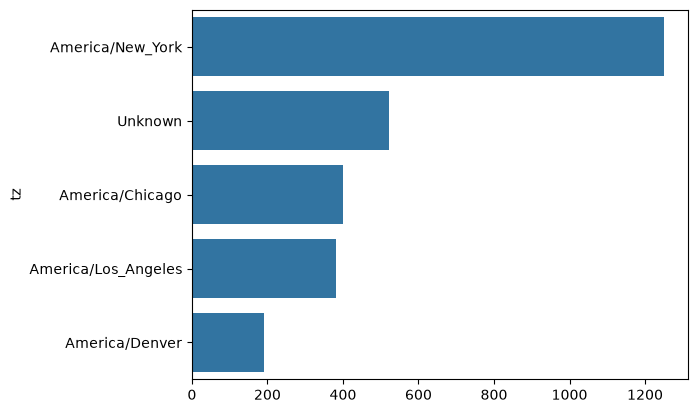

In [31]:
subset = tz_counts.head()
sns.barplot(y=subset.index, x=subset.to_numpy())

In [32]:
frame['a'][1]

'GoogleMaps/RochesterNY'

In [33]:
frame['a'][50]

'Mozilla/5.0 (Windows NT 5.1; rv:10.0.2) Gecko/20100101 Firefox/10.0.2'

In [34]:
frame['a'][51][:50]

'Mozilla/5.0 (Linux; U; Android 2.2.2; en-us; LG-P9'

In [35]:
results = pd.Series([x.split()[0] for x in frame['a'].dropna()])

In [36]:
results.head(5)

0               Mozilla/5.0
1    GoogleMaps/RochesterNY
2               Mozilla/4.0
3               Mozilla/5.0
4               Mozilla/5.0
dtype: str

In [37]:
results.value_counts().head(8)

Mozilla/5.0                 2594
Mozilla/4.0                  601
GoogleMaps/RochesterNY       121
Opera/9.80                    34
TEST_INTERNET_AGENT           24
GoogleProducer                21
Mozilla/6.0                    5
BlackBerry8520/5.0.0.681       4
Name: count, dtype: int64

In [38]:
cframe = frame[frame['a'].notna()].copy()

In [40]:
cframe['os'] = np.where(cframe['a'].str.contains('Windows'),
                        'Windows', 'Not Windows')

In [41]:
cframe['os'].head(5)

0        Windows
1    Not Windows
2        Windows
3    Not Windows
4        Windows
Name: os, dtype: str

In [42]:
by_tz_os = cframe.groupby(['tz', 'os'])

In [43]:
agg_counts = by_tz_os.size().unstack().fillna(0)

In [44]:
agg_counts.head()

os,Not Windows,Windows
tz,,
,245.0,276.0
Africa/Cairo,0.0,3.0
Africa/Casablanca,0.0,1.0
Africa/Ceuta,0.0,2.0
Africa/Johannesburg,0.0,1.0
